## Importing Libraries



In [ ]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from sklearn.metrics import classification_report

## Loading Dataset

In [ ]:
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Data Preprocessing

In [ ]:
max_len = 200   # change to 100 or 300 for experiment

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

## RNN Model

In [ ]:
model_rnn = Sequential([
    Embedding(vocab_size, 128),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn = model_rnn.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7046 - loss: 0.5582 - val_accuracy: 0.7130 - val_loss: 0.5480
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8552 - loss: 0.3397 - val_accuracy: 0.8314 - val_loss: 0.4401
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9477 - loss: 0.1486 - val_accuracy: 0.8306 - val_loss: 0.5501
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9849 - loss: 0.0519 - val_accuracy: 0.8102 - val_loss: 0.6183
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9941 - loss: 0.0213 - val_accuracy: 0.8094 - val_loss: 0.6808


## LSTM Model

In [ ]:
model_lstm = Sequential([
    Embedding(vocab_size, 128),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm = model_lstm.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7623 - loss: 0.4815 - val_accuracy: 0.8598 - val_loss: 0.3333
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8963 - loss: 0.2628 - val_accuracy: 0.8704 - val_loss: 0.3120
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9283 - loss: 0.1906 - val_accuracy: 0.8694 - val_loss: 0.3605
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9528 - loss: 0.1336 - val_accuracy: 0.8694 - val_loss: 0.3792
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9633 - loss: 0.1032 - val_accuracy: 0.8640 - val_loss: 0.4014


## Visualization

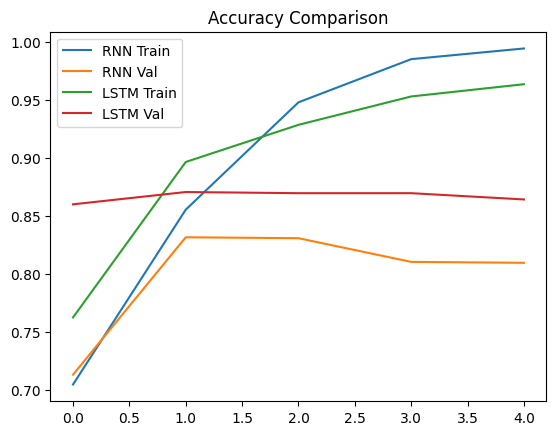

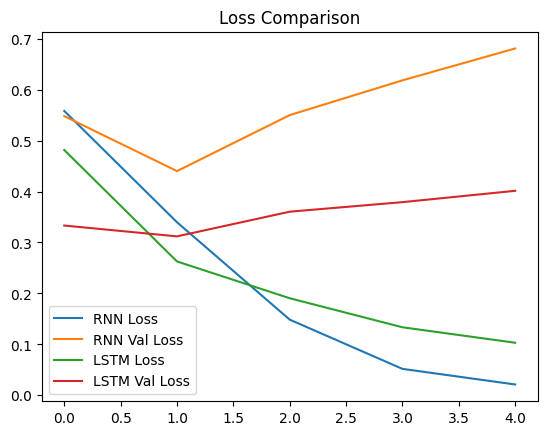

In [ ]:
# Accuracy
plt.plot(history_rnn.history['accuracy'], label='RNN Train')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Val')

plt.plot(history_lstm.history['accuracy'], label='LSTM Train')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val')

plt.legend()
plt.title("Accuracy Comparison")
plt.show()

# Loss
plt.plot(history_rnn.history['loss'], label='RNN Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Val Loss')

plt.plot(history_lstm.history['loss'], label='LSTM Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')

plt.legend()
plt.title("Loss Comparison")
plt.show()

## Model Evaluation

In [ ]:
y_pred = (model_lstm.predict(x_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
              precision    recall  f1-score   support

           0       0.84      0.88      0.86     12500
           1       0.88      0.83      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000

